<a href="https://colab.research.google.com/github/HMBinara/ML_Project/blob/main/Demand_ForecastingML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import pickle



In [29]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('demand_forecasting.csv')

Saving demand_forecasting.csv to demand_forecasting (1).csv


In [30]:
df.shape


(76000, 16)

In [31]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [32]:
features = [
    "Price",
    "Discount",
    "Inventory Level",
    "Competitor Pricing",
    "Promotion",
    "Category"
]


features

['Price',
 'Discount',
 'Inventory Level',
 'Competitor Pricing',
 'Promotion',
 'Category']

In [33]:
target = "Demand"

In [34]:
X = df[features].copy()
X

,Price,Discount,Inventory Level,Competitor Pricing,Promotion,Category
0,72.72,5,195,85.73,0,Electronics
1,80.16,15,117,92.02,1,Clothing
2,62.94,10,247,60.08,1,Clothing
3,87.63,10,139,85.19,0,Electronics
4,54.41,0,152,51.63,0,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,32.23,0,Toys
75996,42.92,5,137,40.73,0,Toys
75997,17.81,10,197,19.41,0,Clothing
75998,151.72,0,125,143.71,0,Furniture


In [35]:
y = df[target]
y

,Demand
0,115
1,229
2,157
3,52
4,59
...,...
75995,64
75996,137
75997,68
75998,84


Convert the Object In Numerical

In [36]:

label_encoders = {}
categorical_cols = X.select_dtypes(include="object").columns

In [37]:
categorical_cols

Index(['Category'], dtype='object')

In [38]:
for col in categorical_cols:
    label_encoder = LabelEncoder()
    X[col] = label_encoder.fit_transform(X[col])
    label_encoders[col] = label_encoder

In [39]:
label_encoder

LabelEncoder()

In [40]:
#Dividing The Traing And Testing Data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [41]:
X

,Price,Discount,Inventory Level,Competitor Pricing,Promotion,Category
0,72.72,5,195,85.73,0,1
1,80.16,15,117,92.02,1,0
2,62.94,10,247,60.08,1,0
3,87.63,10,139,85.19,0,1
4,54.41,0,152,51.63,0,3
...,...,...,...,...,...,...
75995,29.80,5,233,32.23,0,4
75996,42.92,5,137,40.73,0,4
75997,17.81,10,197,19.41,0,0
75998,151.72,0,125,143.71,0,2


In [42]:
xgb = XGBRegressor(objective='reg:squarederror', n_jobs = -1, )

In [49]:
parm_dit = {
    "n_estimators": [200, 300,500],
    "max_depth" : [3,4,6,8],
    "learning_rate":[0.01,0.05,0.1],
    "subsamole":[0.7,0.8,1.0],
    "colsample_bytree":[0.7,0.8,1.0],
    "min_child_weight":[1,3,5]

}

In [52]:
random_search =RandomizedSearchCV(
  estimator=xgb,
  param_distributions=parm_dit,
  n_iter=25,
  scoring="neg_mean_absolute_error",
  cv=3,
  verbose =1,
  n_jobs = -1
)

In [53]:
random_search.fit(X_train,y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:40:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "subsamole" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 500],
                                        'subsamole': [0.7, 0.8, 1.0]},
                   scoring='neg_mean_absolute_error', verbose=1)

In [54]:
random_search.best_params_

{'subsamole': 0.7,
 'n_estimators': 200,
 'min_child_weight': 5,
 'max_depth': 8,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [57]:
best_model = random_search.best_estimator_

In [59]:
y_pred = best_model.predict(X_test)

In [66]:
# Calculate MSE first, then square root it
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(rmse)

35.63134880380092


In [68]:
features_import = pd.Series(
    best_model.feature_importances_, index=X.columns
).sort_values(ascending=False)


In [69]:
features_import

,0
Promotion,0.630748
Category,0.257491
Price,0.063252
Competitor Pricing,0.017140
Discount,0.017046
Inventory Level,0.014323


<Axes: >

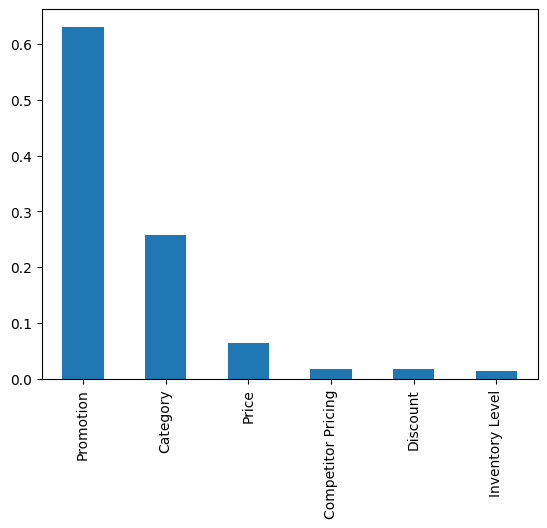

In [71]:
features_import.plot(kind="bar")

In [72]:
with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)


In [73]:
with open("xgboost_demand_model.pkl", "wb") as f:
    pickle.dump(best_model, f)